# Phase 10 — Complexity & Adaptation Metrics (Latency, Rule Count, Adaptation Time) và Phân tích theo Cửa sổ

Hoàn tất nhóm metric còn thiếu của roadmap ban đầu (Phase 9 trong kế hoạch gốc):
- **Complexity:** số luật, số MF, độ trễ suy diễn (inference latency) mỗi mẫu, chi phí một lần thích nghi.
- **Adaptation:** drift detection delay, thời gian tới khi thích nghi xong, mức phục hồi của điểm số.
- **Detection theo cửa sổ thời gian:** trước drift / sau drift chưa thích nghi / sau thích nghi.
- Vẽ lại biểu đồ tổng kết dạng **grouped bar** (thay stacked bar ở Cell 8.15).

Latency phụ thuộc phần cứng. Con số ở đây chỉ dùng để so sánh tương đối giữa Static và Evolving trên cùng máy, không phải cam kết thời gian thực tuyệt đối.

In [1]:
import sys, platform, time
from pathlib import Path
ROOT = Path.cwd().parent; sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src.data import load_dataset, make_scenarios, SUDDEN_DRIFT_POINT, GRADUAL_DRIFT_START, GRADUAL_DRIFT_END
from src.fuzzy import FuzzySystem, STATIC_GRID_MFS, sample_values, TAU, MF_PARAMS
from src.evolving import PrequentialRunner, estimate_shifts, adapt_mfs
from src.evaluation import evaluate
cpu = next((l.split(":")[1].strip() for l in open("/proc/cpuinfo") if l.startswith("model name")), platform.processor()) if Path("/proc/cpuinfo").exists() else platform.processor()
print("CPU:", cpu, "| Python", platform.python_version())
df = load_dataset(); scenarios = make_scenarios(df)

CPU: 13th Gen Intel(R) Core(TM) i7-1355U | Python 3.10.12


## 10.1 — Độ phức tạp cấu trúc

In [2]:
runs = {}
for scen in scenarios:
    for model in ["Static", "Evolving"]:
        r = PrequentialRunner(evolve=(model == "Evolving"), measure_latency=True)
        runs[(scen, model)] = (r, r.run(scenarios[scen]))
struct = []
for (scen, model), (r, log) in runs.items():
    struct.append({"Scenario": scen, "Model": model, "Rules (end)": r.fis.n_rules,
                   "Input MFs": sum(len(v) for v in MF_PARAMS.values()), "Adaptations": int(log.n_adaptations.max()),
                   "Adapted variables": ", ".join(e["variables"] for e in []) or ", ".join(
                       sum([e["variables"] for e in r.events if e["event"] == "adapted"], [])) or "—"})
struct_df = pd.DataFrame(struct); struct_df

,Scenario,Model,Rules (end),Input MFs,Adaptations,Adapted variables
0,Control,Static,12,15,0,—
1,Control,Evolving,12,15,0,—
2,Sudden Drift,Static,12,15,0,—
3,Sudden Drift,Evolving,12,15,1,"rpm, torque"
4,Gradual Drift,Static,12,15,0,—
5,Gradual Drift,Evolving,12,15,1,"rpm, torque"


Số luật **không đổi (12 → 12)** trong mọi kịch bản, vì cơ chế Phase 7 chỉ tịnh tiến MF và không thêm/bớt luật. Rule add/remove được thử riêng ở Phase 12 (bonus).

## 10.2 — Inference latency mỗi mẫu

Đo `time.perf_counter()` quanh bước chấm điểm của từng mẫu, gồm fuzzification, 12 luật và centroid. Static dùng MF giải tích; Evolving sau thích nghi dùng MF trên lưới (`np.interp`). Mỗi cấu hình lặp 5 lần; báo cáo median của các lần lặp.

In [3]:
REPEATS = 5
lat_rows = []
stream = scenarios["Sudden Drift"]
values = [sample_values(r) for _, r in stream.iterrows()]
static = FuzzySystem()
_, sudden_log = runs[("Sudden Drift", "Evolving")]
adapted_fis = runs[("Sudden Drift", "Evolving")][0].fis
for name, fis in [("Static (analytic MFs)", static), ("Evolving (adapted grid MFs)", adapted_fis)]:
    per_rep = []
    for _ in range(REPEATS):
        ts = []
        for v in values:
            t0 = time.perf_counter(); fis.score_values(v); ts.append(time.perf_counter() - t0)
        per_rep.append(np.array(ts) * 1e3)
    arr = np.median(np.vstack(per_rep), axis=0)
    lat_rows.append({"FIS": name, "mean_ms": arr.mean(), "median_ms": np.median(arr),
                     "p95_ms": np.percentile(arr, 95), "p99_ms": np.percentile(arr, 99),
                     "throughput_samples_per_s": 1e3 / arr.mean()})
# full pipeline per sample (score + ADWIN + buffer/adapt bookkeeping)
pipe = []
for _ in range(REPEATS):
    t0 = time.perf_counter(); PrequentialRunner(evolve=True).run(stream); pipe.append((time.perf_counter() - t0) / len(stream) * 1e3)
# one adaptation step
buf = stream.iloc[1184:1384]
ad = []
for _ in range(20):
    t0 = time.perf_counter(); adapt_mfs(STATIC_GRID_MFS, estimate_shifts(buf, STATIC_GRID_MFS, ["rpm", "torque"])); ad.append((time.perf_counter() - t0) * 1e3)
lat_df = pd.DataFrame(lat_rows)
print(lat_df.round(4).to_string(index=False))
print(f"\nFull prequential pipeline (incl. pandas iteration + ADWIN): {np.median(pipe):.3f} ms/sample")
print(f"One adaptation step (estimate + translate 6 MFs): {np.median(ad):.3f} ms")

                        FIS  mean_ms  median_ms  p95_ms  p99_ms  throughput_samples_per_s
      Static (analytic MFs)   0.0684     0.0653  0.0861  0.1024                14612.0021
Evolving (adapted grid MFs)   0.0812     0.0786  0.0950  0.1102                12320.1150

Full prequential pipeline (incl. pandas iteration + ADWIN): 0.167 ms/sample
One adaptation step (estimate + translate 6 MFs): 0.141 ms


## 10.3 — Adaptation metrics

In [4]:
adapt_rows = []
for scen, onset, full in [("Sudden Drift", SUDDEN_DRIFT_POINT, SUDDEN_DRIFT_POINT), ("Gradual Drift", GRADUAL_DRIFT_START, GRADUAL_DRIFT_END)]:
    r, log = runs[(scen, "Evolving")]
    det = [e["t"] for e in r.events if e["event"] == "drift_detected"][0]
    adp = [e for e in r.events if e["event"] == "adapted"][0]
    ctrl = runs[("Control", "Static")][1].score
    post = slice(adp["t"] + 1, 2000)
    adapt_rows.append({"Scenario": scen, "drift onset": onset, "drift fully applied": full,
                       "ADWIN detection t": det, "detection delay (from full drift)": det - full,
                       "adaptation completed t": adp["t"], "onset→adapted (samples)": adp["t"] - onset,
                       "detection→adapted (samples)": adp["t"] - det,
                       "ΔRPM": round(adp["shifts"]["rpm"], 3), "ΔTorque": round(adp["shifts"]["torque"], 4),
                       "post mean score Static": round(runs[(scen, "Static")][1].score[post].mean(), 4),
                       "post mean score Evolving": round(log.score[post].mean(), 4),
                       "post mean score Control (ref)": round(ctrl[post].mean(), 4)})
adapt_df = pd.DataFrame(adapt_rows).T; adapt_df

,0,1
Scenario,Sudden Drift,Gradual Drift
drift onset,1000,800
drift fully applied,1000,1200
ADWIN detection t,1183,1247
detection delay (from full drift),183,47
adaptation completed t,1383,1447
onset→adapted (samples),383,647
detection→adapted (samples),200,200
ΔRPM,-156.214,-161.959
ΔTorque,7.3015,8.053


**Recovery ratio** = (Static − Evolving) / (Static − Control) trên cùng cửa sổ hậu thích nghi. Chỉ số này cho biết cơ chế kéo mặt bằng điểm về gần Control được bao nhiêu phần. 1.0 = về đúng Control; >1 = hạ thấp hơn cả Control (over-correction).

In [5]:
for scen in ["Sudden Drift", "Gradual Drift"]:
    s, e, c = (adapt_df.loc[k, i] for i in [0 if scen.startswith("S") else 1] for k in
               ["post mean score Static", "post mean score Evolving", "post mean score Control (ref)"])
    print(f"{scen}: recovery ratio = {(s - e) / (s - c):.3f}")

Sudden Drift: recovery ratio = 0.988
Gradual Drift: recovery ratio = 1.051


## 10.4 — Detection metrics theo cửa sổ thời gian

Chia luồng thành các đoạn: **A** trước drift, **B** drift đã xảy ra nhưng chưa thích nghi xong (gồm cả độ trễ ADWIN và thời gian thu buffer), **C** sau thích nghi. Mỗi đoạn có rất ít mẫu lỗi (5–15), nên Recall theo từng đoạn **rất nhiễu**: một ca lỗi tương ứng 7–20 điểm phần trăm. Không nên diễn giải chênh lệch Recall nhỏ ở đây như một hiệu ứng có ý nghĩa.

In [6]:
win_rows = []
for scen, onset in [("Sudden Drift", SUDDEN_DRIFT_POINT), ("Gradual Drift", GRADUAL_DRIFT_START)]:
    adp_t = [e["t"] for e in runs[(scen, "Evolving")][0].events if e["event"] == "adapted"][0]
    segs = {"A: pre-drift": (0, onset), "B: drift, not yet adapted": (onset, adp_t + 1), "C: post-adaptation": (adp_t + 1, 2000)}
    for model in ["Static", "Evolving"]:
        log = runs[(scen, model)][1]
        for seg, (a, b) in segs.items():
            w = log.iloc[a:b]; m = evaluate(w.label, w.score, TAU)
            win_rows.append({"Scenario": scen, "Segment": seg, "Model": model, "n": len(w), "failures": int(w.label.sum()),
                             "TP": m["TP"], "FP": m["FP"], "FN": m["FN"], "Precision": m["Precision"], "Recall": m["Recall"],
                             "F1": m["F1"], "FPR": m["FPR"]})
win_df = pd.DataFrame(win_rows)
win_df.round(4)

,Scenario,Segment,Model,n,failures,TP,FP,FN,Precision,Recall,F1,FPR
0,Sudden Drift,A: pre-drift,Static,1000,17,3,22,14,0.1200,0.1765,0.1429,0.0224
1,Sudden Drift,"B: drift, not yet adapted",Static,384,7,4,28,3,0.1250,0.5714,0.2051,0.0743
2,Sudden Drift,C: post-adaptation,Static,616,15,11,64,4,0.1467,0.7333,0.2444,0.1065
3,Sudden Drift,A: pre-drift,Evolving,1000,17,3,22,14,0.1200,0.1765,0.1429,0.0224
4,Sudden Drift,"B: drift, not yet adapted",Evolving,384,7,4,28,3,0.1250,0.5714,0.2051,0.0743
5,Sudden Drift,C: post-adaptation,Evolving,616,15,8,6,7,0.5714,0.5333,0.5517,0.0100
6,Gradual Drift,A: pre-drift,Static,800,15,2,19,13,0.0952,0.1333,0.1111,0.0242
7,Gradual Drift,"B: drift, not yet adapted",Static,648,10,6,39,4,0.1333,0.6000,0.2182,0.0611
8,Gradual Drift,C: post-adaptation,Static,552,14,10,55,4,0.1538,0.7143,0.2532,0.1022
9,Gradual Drift,A: pre-drift,Evolving,800,15,2,19,13,0.0952,0.1333,0.1111,0.0242


## 10.4b — So với tham chiếu "không drift" trên cùng cửa sổ

Static có Recall cao hơn Evolving ở đoạn C, nhưng một phần là **do chính drift**: RPM thấp và Torque cao đẩy mọi điểm số lên, nên ngoài ca lỗi thật còn có FP tăng gấp khoảng 10 lần. Tham chiếu công bằng hơn là **hệ Static trên luồng Control ở cùng cửa sổ thời gian**, tức hệ thống sẽ hoạt động thế nào nếu drift không xảy ra. Đây là tham chiếu *oracle*, chỉ dùng để đánh giá, không dùng được khi vận hành.

In [7]:
ctrl_log = runs[("Control", "Static")][1]
ref_rows = []
for scen in ["Sudden Drift", "Gradual Drift"]:
    adp_t = [e["t"] for e in runs[(scen, "Evolving")][0].events if e["event"] == "adapted"][0]
    for name, log in [("Static (drifted)", runs[(scen, "Static")][1]), ("Evolving (drifted)", runs[(scen, "Evolving")][1]), ("Control reference (no drift)", ctrl_log)]:
        w = log.iloc[adp_t + 1:]; m = evaluate(w.label, w.score, TAU)
        ref_rows.append({"Scenario": scen, "Window C": f"{adp_t+1}–1999", "System": name, "TP": m["TP"], "FP": m["FP"], "FN": m["FN"],
                         "Precision": m["Precision"], "Recall": m["Recall"], "F1": m["F1"], "FPR": m["FPR"]})
ref_df = pd.DataFrame(ref_rows); ref_df.round(4)

,Scenario,Window C,System,TP,FP,FN,Precision,Recall,F1,FPR
0,Sudden Drift,1384–1999,Static (drifted),11,64,4,0.1467,0.7333,0.2444,0.1065
1,Sudden Drift,1384–1999,Evolving (drifted),8,6,7,0.5714,0.5333,0.5517,0.0100
2,Sudden Drift,1384–1999,Control reference (no drift),8,6,7,0.5714,0.5333,0.5517,0.0100
3,Gradual Drift,1448–1999,Static (drifted),10,55,4,0.1538,0.7143,0.2532,0.1022
4,Gradual Drift,1448–1999,Evolving (drifted),6,3,8,0.6667,0.4286,0.5217,0.0056
5,Gradual Drift,1448–1999,Control reference (no drift),7,5,7,0.5833,0.5000,0.5385,0.0093


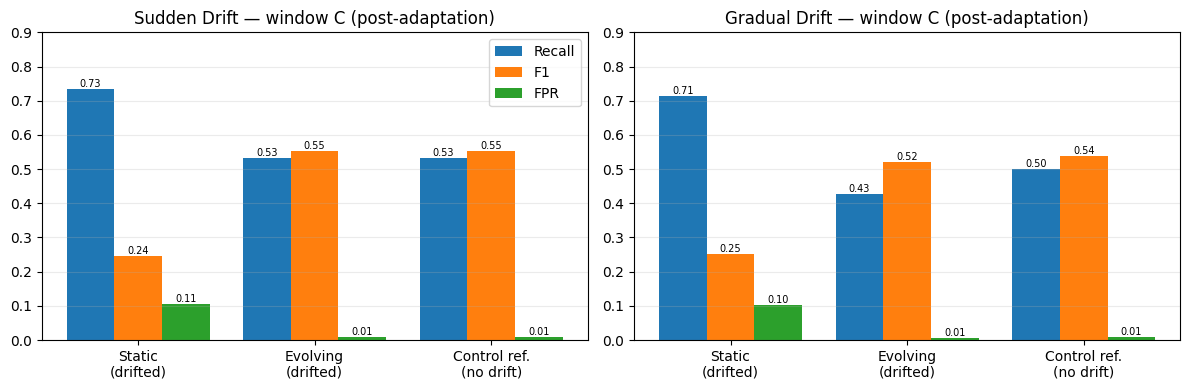

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, scen in zip(axes, ["Sudden Drift", "Gradual Drift"]):
    d = ref_df[ref_df.Scenario == scen]
    x = np.arange(3); w = 0.27
    for j, met in enumerate(["Recall", "F1", "FPR"]):
        bars = ax.bar(x + (j - 1) * w, d[met], w, label=met)
        for b in bars: ax.text(b.get_x() + b.get_width()/2, b.get_height(), f"{b.get_height():.2f}", ha="center", va="bottom", fontsize=7)
    ax.set_xticks(x); ax.set_xticklabels(["Static\n(drifted)", "Evolving\n(drifted)", "Control ref.\n(no drift)"]); ax.set_title(f"{scen} — window C (post-adaptation)")
    ax.set_ylim(0, 0.9); ax.grid(axis="y", alpha=.25)
axes[0].legend()
plt.tight_layout(); plt.savefig(ROOT / "figures" / "10_window_c_vs_control_reference.png", dpi=130); plt.show()

## 10.5 — Biểu đồ tổng kết grouped bar (thay Cell 8.15)

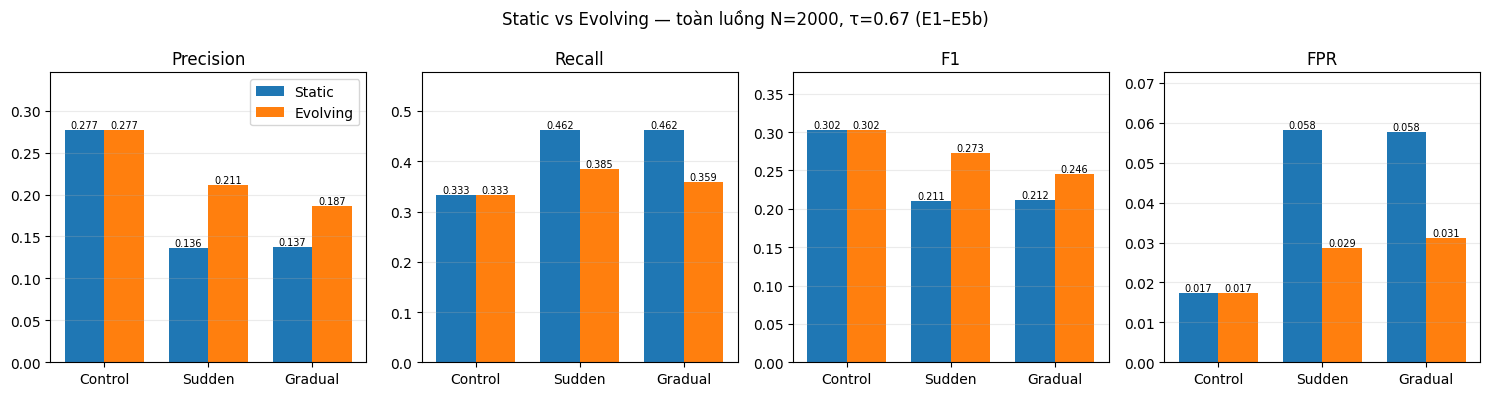

In [9]:
mat = pd.read_csv(ROOT / "results" / "09_experiment_matrix.csv")
metrics = ["Precision", "Recall", "F1", "FPR"]
fig, axes = plt.subplots(1, 4, figsize=(15, 4), sharey=False)
scen_order = ["Control", "Sudden Drift", "Gradual Drift"]
x = np.arange(len(scen_order)); w = 0.38
for ax, met in zip(axes, metrics):
    sv = [mat[(mat.Scenario == s) & (mat.Model == "Static")][met].iloc[0] for s in scen_order]
    ev = [mat[(mat.Scenario == s) & (mat.Model == "Evolving")][met].iloc[0] for s in scen_order]
    b1 = ax.bar(x - w/2, sv, w, label="Static"); b2 = ax.bar(x + w/2, ev, w, label="Evolving")
    for b in list(b1) + list(b2):
        ax.text(b.get_x() + b.get_width()/2, b.get_height(), f"{b.get_height():.3f}", ha="center", va="bottom", fontsize=7)
    ax.set_xticks(x); ax.set_xticklabels(["Control", "Sudden", "Gradual"]); ax.set_title(met); ax.grid(axis="y", alpha=.25)
    ax.set_ylim(0, max(max(sv), max(ev)) * 1.25)
axes[0].legend()
fig.suptitle("Static vs Evolving — toàn luồng N=2000, τ=0.67 (E1–E5b)")
plt.tight_layout(); plt.savefig(ROOT / "figures" / "10_final_metrics_grouped.png", dpi=130); plt.show()

## 10.6 — Lưu kết quả

In [10]:
struct_df.to_csv(ROOT / "results" / "10_structure.csv", index=False)
lat_df.assign(pipeline_ms_per_sample=np.median(pipe), adaptation_step_ms=np.median(ad), cpu=cpu).to_csv(ROOT / "results" / "10_latency.csv", index=False)
adapt_df.to_csv(ROOT / "results" / "10_adaptation_metrics.csv")
win_df.to_csv(ROOT / "results" / "10_window_metrics.csv", index=False)
ref_df.to_csv(ROOT / "results" / "10_window_c_vs_control_reference.csv", index=False)
print("Phase 10: COMPLETE")

Phase 10: COMPLETE
